# Classifiers_KNN_SVM_MLP
This project's goal is to construct, train and analyze performances between the following classifiers: K Nearest Neighbors;  Support Vector Machines; Multi-Layer Perceptron

### Importing Libraries

In [19]:
from sklearn.datasets import load_iris
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
# for the classifiers
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier as KNN # K-Nearest Neighbors
from sklearn.svm import SVC # Support Vector Classifier
from sklearn.neural_network import MLPClassifier as MLP # Multi-layer Perceptron

## Iris Dataset

Looking at the Iris dataset and testing the KNN classifier on it. 

In [20]:
X, y = load_iris(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
knn = KNN().fit(X_tr, y_tr)
print("Accuracy: " + str(knn.score(X_te, y_te)) + "/1.0\n")

for i in range(10):
    print(X_te[i], y_te[i], knn.predict([X_te[i]]))

Accuracy: 1.0/1.0

[4.4 3.  1.3 0.2] 0 [0]
[6.1 3.  4.9 1.8] 2 [2]
[4.9 2.4 3.3 1. ] 1 [1]
[5.  2.3 3.3 1. ] 1 [1]
[4.4 3.2 1.3 0.2] 0 [0]
[6.3 3.3 4.7 1.6] 1 [1]
[4.6 3.6 1.  0.2] 0 [0]
[5.4 3.4 1.7 0.2] 0 [0]
[6.5 3.  5.2 2. ] 2 [2]
[5.4 3.  4.5 1.5] 1 [1]


## Digits Dataset

Looking at the Digits dataset by printing first 10 images with their labels, the number of samples for each label and its shape.

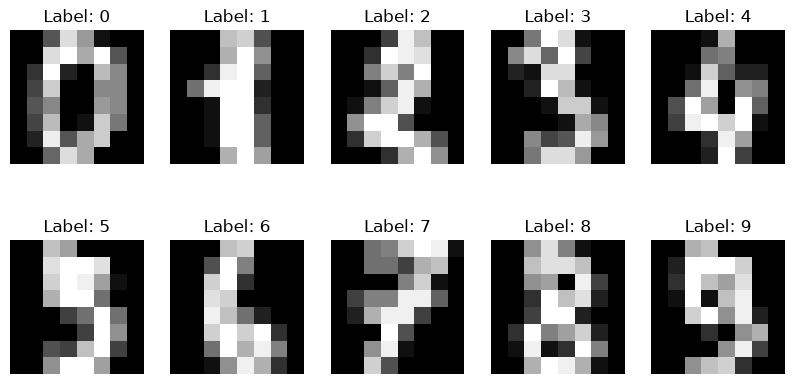

0:178   1:182   2:177   3:183   4:181   5:182   6:181   7:179   8:174   9:180  
X shape: (1797, 64) | y shape: (1797,)


In [21]:
digits = load_digits()
X, y = digits.data, digits.target
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.axis('off')
    plt.imshow(digits.images[i], cmap='grey')
    plt.title(f"Label: {digits.target[i]}")
plt.show()

print(*(str(i) + ":" + str(np.bincount(y)[i]) + "  " for i in range(10)))
print("X shape: {} | y shape: {}".format(X.shape, y.shape))

### Classifiers
>Note: Since the digits dataset has a small range of values, using StandarScaler to scale the data may not be necessary. Either way, I'll include both to see if there are any performance differences.
#### K Nearest Neighbors
- With StandardScaler:

In [22]:
pipe = make_pipeline(StandardScaler(), KNN())
grid = GridSearchCV(pipe, {"kneighborsclassifier__n_neighbors": [1, 3, 5, 7], "kneighborsclassifier__weights": ["uniform", "distance"]}, cv=5)
grid.fit(X_tr, y_tr)
print(grid.best_params_, grid.best_score_)
print("Accuracy: {:.3f}".format(grid.score(X_te, y_te)) + "/1.000\n")

{'kneighborsclassifier__n_neighbors': 5, 'kneighborsclassifier__weights': 'uniform'} 0.9749298296554393
Accuracy: 0.964/1.000



- Without StandardScaler:

In [23]:
grid = GridSearchCV(KNN(), {"n_neighbors": [1, 3, 5, 7], "weights": ["uniform", "distance"]}, cv=5)
grid.fit(X_tr, y_tr)
print(grid.best_params_, grid.best_score_)
print("Accuracy: {:.3f}".format(grid.score(X_te, y_te)) + "/1.000\n")

{'n_neighbors': 1, 'weights': 'uniform'} 0.9902463221060781
Accuracy: 0.986/1.000



---
#### Support Vector Machines
- With StandardScaler:

In [38]:
pipe = make_pipeline(StandardScaler(), SVC())
grid = GridSearchCV(pipe, {"svc__C": [0.1, 1, 10], "svc__gamma": ["scale", 0.01, 0.001], "svc__kernel": ["linear", "rbf"]}, cv=5)
grid.fit(X_tr, y_tr)
print(grid.best_params_, grid.best_score_)
print("Accuracy: {:.3f}".format(grid.score(X_te, y_te)) + "/1.000\n")

{'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'} 0.9832970383275261
Accuracy: 0.975/1.000



- Without StandardScaler:

In [39]:
grid = GridSearchCV(SVC(), 
                    [{"C": [0.1, 1, 10, 100], "gamma": ["scale", 0.01, 0.001, 0.0005, 0.0001], "kernel": ["rbf"]},
                    {"C": [0.1, 1, 10, 100], "kernel": ["linear"]}], 
                    cv=5)
grid.fit(X_tr, y_tr)
print(grid.best_params_, grid.best_score_)
print("Accuracy: {:.3f}".format(grid.score(X_te, y_te)) + "/1.000\n")

{'C': 1, 'gamma': 0.0005, 'kernel': 'rbf'} 0.9902560007742934
Accuracy: 0.992/1.000



>At first C was highest value was 10 and gamma lowest was 0.001 and the grid search chose those 2 results, so I added [100] and [0.0005, 0.0001] respectively to see if it was because of the boundaries.
>Results: The best parameters became C=1 and gamma=0.0005, which means the boundaries were affecting the results.

---
##### Conlusions about StandardScaler for KNN and SVM
For this dataset, using StandardScaler has a negative effect, the accuracy is lower. This is probably because all the pixels are in the same 0-16 range, so 

---
#### Multi-Layer Perceptron
- With StandardScaler:

In [28]:
pipe = make_pipeline(StandardScaler(), MLP())
grid = GridSearchCV(pipe, {"mlpclassifier__hidden_layer_sizes": [(64,), (128,), (128, 64)], "mlpclassifier__alpha": [0.0001, 0.001, 0.01], "mlpclassifier__max_iter": [1000]}, cv=5)
grid.fit(X_tr, y_tr)
print(grid.best_params_, grid.best_score_)
print("Accuracy: {:.3f}".format(grid.score(X_te, y_te)) + "/1.000\n")

{'mlpclassifier__alpha': 0.001, 'mlpclassifier__hidden_layer_sizes': (128,), 'mlpclassifier__max_iter': 1000} 0.9805120015485869
Accuracy: 0.981/1.000



- Without StandardScaler:

In [29]:
grid = GridSearchCV(MLP(), {"hidden_layer_sizes": [(64,), (128,), (128, 64)], "alpha": [0.0001, 0.001, 0.01], "max_iter": [1000]}, cv=5)
grid.fit(X_tr, y_tr)
print(grid.best_params_, grid.best_score_)
print("Accuracy: {:.3f}".format(grid.score(X_te, y_te)) + "/1.000\n")

{'alpha': 0.001, 'hidden_layer_sizes': (128, 64), 'max_iter': 1000} 0.9770325203252032
Accuracy: 0.989/1.000

